# Project V Milestone 2 — Advanced Clustering Baseline Comparison

This notebook compares HDBSCAN, OPTICS, and Gaussian Mixture Models in the
five-dimensional Project V core feature space.

## Blind-analysis design

1. Construct the discovery matrix without candidate flags.
2. Select and lock algorithm configurations using only internal structure metrics.
3. Load the 27-object external candidate set only after model selection.
4. Measure candidate recovery, group concentration, and enrichment.

Cluster assignments are exploratory feature-space structures rather than confirmed
astrophysical populations.


In [1]:
# PROJECT_V_REPO_ROOT_FIX
import os
from pathlib import Path

working_directory = Path.cwd().resolve()

repo_candidates = [
    working_directory,
    working_directory.parent,
]

repo_root = next(
    (
        candidate
        for candidate in repo_candidates
        if (
            candidate
            / "data"
            / "processed"
            / "gaia_lamost_larger_chemo_kinematic_features.csv"
        ).exists()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the repository root or Project V parent sample."
    )

os.chdir(repo_root)

print("Repository root:", Path.cwd())
print(
    "Parent sample exists:",
    Path(
        "data/processed/"
        "gaia_lamost_larger_chemo_kinematic_features.csv"
    ).exists(),
)


Repository root: /Users/liors/Documents/research/gaia-lamost-galactic-archaeology
Parent sample exists: True


In [2]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.cluster import HDBSCAN, OPTICS, cluster_optics_xi
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)


Python: 3.12.7
scikit-learn: 1.9.0


## 1. Build the blinded discovery matrix

Only source identifiers and the five predeclared core features are retained.
Existing candidate flags are deliberately excluded.


In [3]:
parent_path = Path(
    "data/processed/gaia_lamost_larger_chemo_kinematic_features.csv"
)

core_features = [
    "feh",
    "rv",
    "tangential_velocity_kms",
    "bp_rp",
    "absolute_g_mag",
]

parent_raw = pd.read_csv(parent_path)

discovery = parent_raw[
    ["source_id"] + core_features
].copy()

assert len(discovery) == 1838
assert discovery["source_id"].nunique() == len(discovery)
assert discovery[core_features].notna().all().all()

scaler = RobustScaler()
X = scaler.fit_transform(discovery[core_features])

print("Discovery rows:", len(discovery))
print("Feature count:", len(core_features))
print("Candidate information loaded:", False)


Discovery rows: 1838
Feature count: 5
Candidate information loaded: False


## 2. Internal clustering metrics

In [4]:
def clustering_structure(labels):
    labels = np.asarray(labels)
    clustered_mask = labels != -1
    clustered_labels = labels[clustered_mask]

    unique_clusters = np.unique(clustered_labels)
    n_clusters = len(unique_clusters)
    noise_count = int((labels == -1).sum())
    clustered_count = int(clustered_mask.sum())

    if n_clusters:
        counts = pd.Series(clustered_labels).value_counts()
        smallest_cluster = int(counts.min())
        largest_cluster = int(counts.max())
    else:
        smallest_cluster = 0
        largest_cluster = 0

    result = {
        "n_clusters": n_clusters,
        "noise_count": noise_count,
        "noise_fraction": noise_count / len(labels),
        "clustered_count": clustered_count,
        "clustered_fraction": clustered_count / len(labels),
        "smallest_cluster": smallest_cluster,
        "largest_cluster": largest_cluster,
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    if (
        n_clusters >= 2
        and clustered_count > n_clusters
        and smallest_cluster >= 2
    ):
        X_clustered = X[clustered_mask]

        result["silhouette"] = silhouette_score(
            X_clustered,
            clustered_labels,
            sample_size=min(1000, clustered_count),
            random_state=RANDOM_STATE,
        )
        result["calinski_harabasz"] = calinski_harabasz_score(
            X_clustered,
            clustered_labels,
        )
        result["davies_bouldin"] = davies_bouldin_score(
            X_clustered,
            clustered_labels,
        )

    return result


def add_density_selection_columns(table):
    table = table.copy()

    table["admissible"] = (
        (table["n_clusters"] >= 2)
        & (table["clustered_fraction"] >= 0.50)
        & (table["smallest_cluster"] >= 5)
        & table["silhouette"].notna()
    )

    table["selection_score"] = (
        table["silhouette"].fillna(-1.0)
        + 0.15 * table["clustered_fraction"]
    )

    return table


def select_density_configuration(table):
    admissible = table[table["admissible"]].copy()

    if len(admissible):
        pool = admissible
        selection_rule = "admissible_internal_structure"
    else:
        multi_cluster = table[
            (table["n_clusters"] >= 2)
            & table["silhouette"].notna()
        ].copy()

        if len(multi_cluster):
            pool = multi_cluster
            selection_rule = "fallback_multi_cluster"
        else:
            pool = table.copy()
            selection_rule = "fallback_maximum_coverage"

    selected = pool.sort_values(
        ["selection_score", "clustered_fraction", "smallest_cluster"],
        ascending=[False, False, False],
    ).iloc[0].copy()

    selected["selection_rule"] = selection_rule
    return selected


## 3. Blind HDBSCAN parameter comparison

The grid varies minimum cluster size, density conservatism, and cluster-selection
method. No candidate information is available during this step.


In [5]:
hdbscan_rows = []
hdbscan_label_cache = {}

for min_cluster_size in [15, 25, 40, 60]:
    for min_samples in [5, 10, 20]:
        for selection_method in ["eom", "leaf"]:
            model = HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_method=selection_method,
                allow_single_cluster=False,
            )

            labels = model.fit_predict(X)
            key = (min_cluster_size, min_samples, selection_method)
            hdbscan_label_cache[key] = labels.copy()

            hdbscan_rows.append(
                {
                    "algorithm": "HDBSCAN",
                    "min_cluster_size": min_cluster_size,
                    "min_samples": min_samples,
                    "cluster_selection_method": selection_method,
                    **clustering_structure(labels),
                }
            )

hdbscan_results = add_density_selection_columns(
    pd.DataFrame(hdbscan_rows)
)

hdbscan_locked = select_density_configuration(hdbscan_results)

hdbscan_locked.to_frame().T


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/

,algorithm,min_cluster_size,min_samples,cluster_selection_method,n_clusters,noise_count,noise_fraction,clustered_count,clustered_fraction,smallest_cluster,largest_cluster,silhouette,calinski_harabasz,davies_bouldin,admissible,selection_score,selection_rule
4,HDBSCAN,15,20,eom,2,804,0.437432,1034,0.562568,136,898,0.406819,429.958913,0.899796,True,0.491204,admissible_internal_structure


## 4. Blind OPTICS parameter comparison

OPTICS is evaluated through its density ordering and xi-based extraction.


In [6]:
optics_rows = []
optics_label_cache = {}

# Fit one reachability graph per min_samples value, then reuse it
# when extracting clusters with different xi and cluster-size settings.
for min_samples in [10, 20, 30]:
    print(f"Fitting OPTICS graph: min_samples={min_samples}", flush=True)

    model = OPTICS(
        min_samples=min_samples,
        metric="euclidean",
        algorithm="auto",
        n_jobs=-1,
    )
    model.fit(X)

    for xi in [0.03, 0.05, 0.08]:
        for min_cluster_size in [0.02, 0.04, 0.06]:
            labels, _ = cluster_optics_xi(
                reachability=model.reachability_,
                predecessor=model.predecessor_,
                ordering=model.ordering_,
                min_samples=min_samples,
                xi=xi,
                min_cluster_size=min_cluster_size,
            )

            key = (min_samples, xi, min_cluster_size)
            optics_label_cache[key] = labels.copy()

            optics_rows.append(
                {
                    "algorithm": "OPTICS",
                    "min_samples": min_samples,
                    "xi": xi,
                    "min_cluster_size": min_cluster_size,
                    **clustering_structure(labels),
                }
            )

            print(
                f"  extracted xi={xi}, "
                f"min_cluster_size={min_cluster_size}",
                flush=True,
            )

optics_results = add_density_selection_columns(
    pd.DataFrame(optics_rows)
)

optics_locked = select_density_configuration(optics_results)

print("OPTICS comparison complete", flush=True)
optics_locked.to_frame().T


Fitting OPTICS graph: min_samples=10


  extracted xi=0.03, min_cluster_size=0.02


  extracted xi=0.03, min_cluster_size=0.04


  extracted xi=0.03, min_cluster_size=0.06


  extracted xi=0.05, min_cluster_size=0.02


...

  extracted xi=0.08, min_cluster_size=0.02


  extracted xi=0.08, min_cluster_size=0.04


  extracted xi=0.08, min_cluster_size=0.06


OPTICS comparison complete


,algorithm,min_samples,xi,min_cluster_size,n_clusters,noise_count,noise_fraction,clustered_count,clustered_fraction,smallest_cluster,largest_cluster,silhouette,calinski_harabasz,davies_bouldin,admissible,selection_score,selection_rule
0,OPTICS,10,0.03,0.02,1,0,0.0,1838,1.0,1838,1838,NaN,NaN,NaN,False,-0.85,fallback_maximum_coverage


## 5. Blind Gaussian Mixture Model comparison

GMM component count and covariance structure are selected by minimum Bayesian
Information Criterion. Candidate recovery is not part of this decision.


In [7]:
gmm_rows = []

for covariance_type in ["full", "tied", "diag", "spherical"]:
    for n_components in range(1, 11):
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            n_init=5,
            random_state=RANDOM_STATE,
            reg_covar=1e-6,
        )
        model.fit(X)

        labels = model.predict(X)
        metrics = clustering_structure(labels)

        gmm_rows.append(
            {
                "algorithm": "GMM",
                "n_components": n_components,
                "covariance_type": covariance_type,
                "bic": model.bic(X),
                "aic": model.aic(X),
                "converged": model.converged_,
                **metrics,
            }
        )

gmm_results = pd.DataFrame(gmm_rows)

gmm_locked = (
    gmm_results[
        gmm_results["converged"]
    ]
    .sort_values(["bic", "aic"], ascending=[True, True])
    .iloc[0]
    .copy()
)

gmm_locked["selection_rule"] = "minimum_bic"

gmm_locked.to_frame().T


,algorithm,n_components,covariance_type,bic,aic,converged,n_clusters,noise_count,noise_fraction,clustered_count,clustered_fraction,smallest_cluster,largest_cluster,silhouette,calinski_harabasz,davies_bouldin,selection_rule
8,GMM,9,full,16518.065978,15480.976517,True,9,0,0.0,1838,1.0,32,337,0.059371,221.658579,2.770307,minimum_bic


## 6. Lock all models before candidate reveal

The following configurations are frozen using only the discovery feature matrix.


In [8]:
hdbscan_key = (
    int(hdbscan_locked["min_cluster_size"]),
    int(hdbscan_locked["min_samples"]),
    str(hdbscan_locked["cluster_selection_method"]),
)

optics_key = (
    int(optics_locked["min_samples"]),
    float(optics_locked["xi"]),
    float(optics_locked["min_cluster_size"]),
)

hdbscan_labels = hdbscan_label_cache[hdbscan_key]
optics_labels = optics_label_cache[optics_key]

gmm_model = GaussianMixture(
    n_components=int(gmm_locked["n_components"]),
    covariance_type=str(gmm_locked["covariance_type"]),
    n_init=5,
    random_state=RANDOM_STATE,
    reg_covar=1e-6,
)
gmm_model.fit(X)

gmm_labels = gmm_model.predict(X)
gmm_probabilities = gmm_model.predict_proba(X).max(axis=1)

locked_summary = pd.DataFrame(
    [
        {
            "algorithm": "HDBSCAN",
            "selection_rule": hdbscan_locked["selection_rule"],
            "parameters": json.dumps(
                {
                    "min_cluster_size": hdbscan_key[0],
                    "min_samples": hdbscan_key[1],
                    "cluster_selection_method": hdbscan_key[2],
                },
                sort_keys=True,
            ),
            **clustering_structure(hdbscan_labels),
            "bic": np.nan,
            "aic": np.nan,
        },
        {
            "algorithm": "OPTICS",
            "selection_rule": optics_locked["selection_rule"],
            "parameters": json.dumps(
                {
                    "min_samples": optics_key[0],
                    "xi": optics_key[1],
                    "min_cluster_size": optics_key[2],
                },
                sort_keys=True,
            ),
            **clustering_structure(optics_labels),
            "bic": np.nan,
            "aic": np.nan,
        },
        {
            "algorithm": "GMM",
            "selection_rule": "minimum_bic",
            "parameters": json.dumps(
                {
                    "n_components": int(gmm_locked["n_components"]),
                    "covariance_type": str(gmm_locked["covariance_type"]),
                },
                sort_keys=True,
            ),
            **clustering_structure(gmm_labels),
            "bic": float(gmm_locked["bic"]),
            "aic": float(gmm_locked["aic"]),
        },
    ]
)

print("MODEL CONFIGURATIONS LOCKED")
locked_summary


MODEL CONFIGURATIONS LOCKED


,algorithm,selection_rule,parameters,n_clusters,noise_count,noise_fraction,clustered_count,clustered_fraction,smallest_cluster,largest_cluster,silhouette,calinski_harabasz,davies_bouldin,bic,aic
0,HDBSCAN,admissible_internal_structure,"{""cluster_selection_method"": ""eom"", ""min_clust...",2,804,0.437432,1034,0.562568,136,898,0.406819,429.958913,0.899796,NaN,NaN
1,OPTICS,fallback_maximum_coverage,"{""min_cluster_size"": 0.02, ""min_samples"": 10, ...",1,0,0.000000,1838,1.000000,1838,1838,NaN,NaN,NaN,NaN,NaN
2,GMM,minimum_bic,"{""covariance_type"": ""full"", ""n_components"": 9}",9,0,0.000000,1838,1.000000,32,337,0.059371,221.658579,2.770307,16518.065978,15480.976517


## 7. Reveal the external candidate set

The candidate catalogue is loaded only after all three model configurations have
been locked.


In [9]:
candidate_path = Path(
    "data/processed/project_v_candidate_cross_method_summary.csv"
)
known_candidates = pd.read_csv(candidate_path)

def source_id_key(series):
    return pd.to_numeric(series, errors="raise").astype("Int64").astype(str)

candidate_ids = set(source_id_key(known_candidates["source_id"]))

assignments = discovery.copy()
assignments["source_id_key"] = source_id_key(assignments["source_id"])
assignments["known_candidate"] = assignments[
    "source_id_key"
].isin(candidate_ids)

assignments["hdbscan_label"] = hdbscan_labels
assignments["optics_label"] = optics_labels
assignments["gmm_label"] = gmm_labels
assignments["gmm_membership_probability"] = gmm_probabilities

assert assignments["known_candidate"].sum() == 27

print("Candidate set revealed:", True)
print("Known candidates recovered in parent:", assignments["known_candidate"].sum())


Candidate set revealed: True
Known candidates recovered in parent: 27


## 8. Candidate recovery and enrichment

In [10]:
global_candidate_rate = assignments["known_candidate"].mean()
known_candidate_count = int(assignments["known_candidate"].sum())

group_rows = []
recovery_rows = []

label_columns = {
    "HDBSCAN": "hdbscan_label",
    "OPTICS": "optics_label",
    "GMM": "gmm_label",
}

for algorithm, label_column in label_columns.items():
    algorithm_groups = []

    for label, group in assignments.groupby(label_column):
        candidate_count = int(group["known_candidate"].sum())
        group_size = len(group)
        candidate_fraction = candidate_count / group_size
        candidate_recall = candidate_count / known_candidate_count

        row = {
            "algorithm": algorithm,
            "label": int(label),
            "is_noise": bool(label == -1),
            "group_size": group_size,
            "candidate_count": candidate_count,
            "candidate_fraction": candidate_fraction,
            "candidate_recall": candidate_recall,
            "enrichment_over_parent": (
                candidate_fraction / global_candidate_rate
            ),
        }

        group_rows.append(row)
        algorithm_groups.append(row)

    group_table = pd.DataFrame(algorithm_groups)
    non_noise = group_table[group_table["label"] != -1].copy()

    if len(non_noise):
        best_group = non_noise.sort_values(
            ["candidate_count", "enrichment_over_parent", "group_size"],
            ascending=[False, False, True],
        ).iloc[0]
    else:
        best_group = pd.Series(
            {
                "label": np.nan,
                "group_size": 0,
                "candidate_count": 0,
                "candidate_recall": 0.0,
                "enrichment_over_parent": np.nan,
            }
        )

    noise_group = group_table[group_table["label"] == -1]
    noise_candidate_count = (
        int(noise_group.iloc[0]["candidate_count"])
        if len(noise_group)
        else 0
    )

    non_noise_candidate_count = int(
        assignments.loc[
            assignments[label_column] != -1,
            "known_candidate",
        ].sum()
    )

    recovery_rows.append(
        {
            "algorithm": algorithm,
            "known_candidate_count": known_candidate_count,
            "candidates_in_non_noise_groups": non_noise_candidate_count,
            "non_noise_candidate_recovery_fraction": (
                non_noise_candidate_count / known_candidate_count
            ),
            "candidates_assigned_to_noise": noise_candidate_count,
            "noise_candidate_fraction": (
                noise_candidate_count / known_candidate_count
            ),
            "best_non_noise_group_label": best_group["label"],
            "best_non_noise_group_size": int(best_group["group_size"]),
            "best_non_noise_group_candidate_count": int(
                best_group["candidate_count"]
            ),
            "best_non_noise_group_candidate_recall": float(
                best_group["candidate_recall"]
            ),
            "best_non_noise_group_enrichment": float(
                best_group["enrichment_over_parent"]
            ),
        }
    )

candidate_recovery_by_group = pd.DataFrame(group_rows)
candidate_recovery_summary = pd.DataFrame(recovery_rows)

candidate_recovery_summary


,algorithm,known_candidate_count,candidates_in_non_noise_groups,non_noise_candidate_recovery_fraction,candidates_assigned_to_noise,noise_candidate_fraction,best_non_noise_group_label,best_non_noise_group_size,best_non_noise_group_candidate_count,best_non_noise_group_candidate_recall,best_non_noise_group_enrichment
0,HDBSCAN,27,0,0.0,27,1.0,1,136,0,0.000000,0.000000
1,OPTICS,27,27,1.0,0,0.0,0,1838,27,1.000000,1.000000
2,GMM,27,27,1.0,0,0.0,5,32,24,0.888889,51.055556


## 9. Model-selection diagnostics

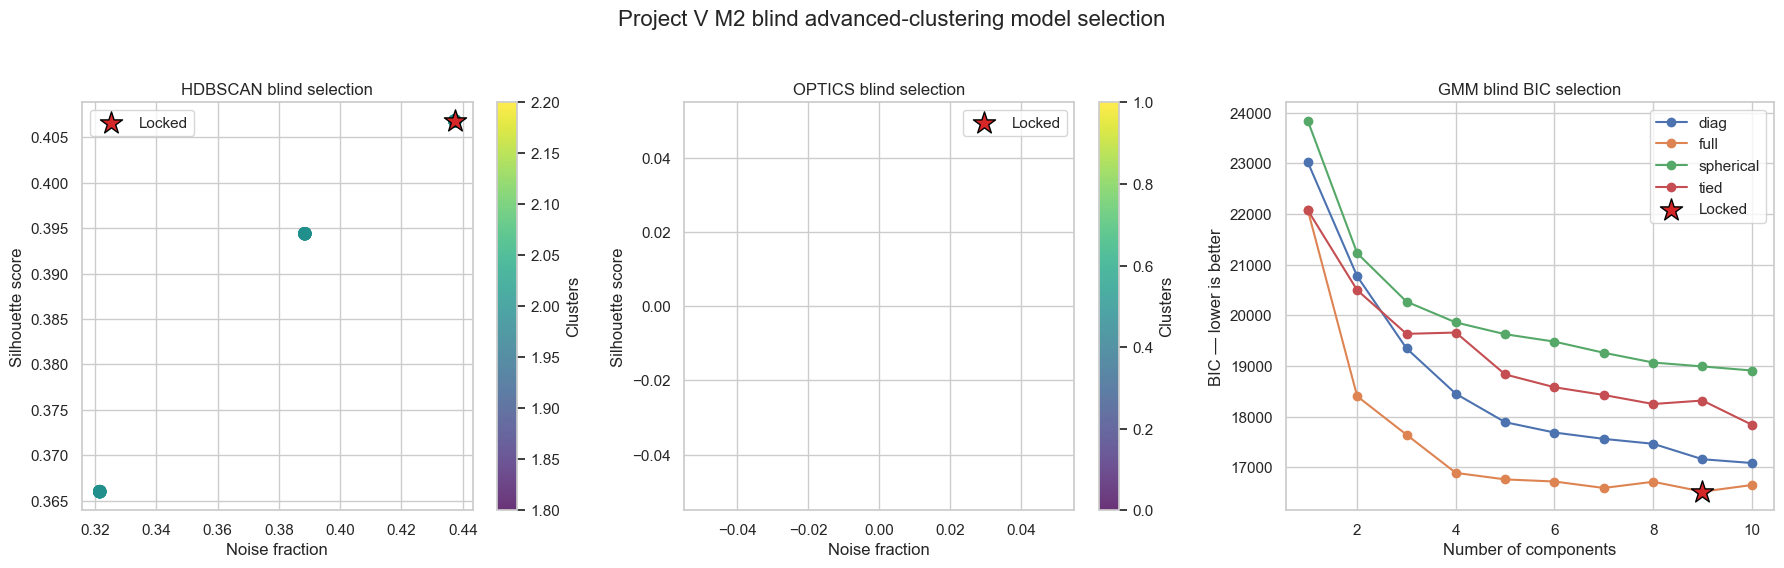

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

hdb_plot = hdbscan_results.dropna(subset=["silhouette"])
scatter = axes[0].scatter(
    hdb_plot["noise_fraction"],
    hdb_plot["silhouette"],
    c=hdb_plot["n_clusters"],
    cmap="viridis",
    s=75,
    alpha=0.8,
)
axes[0].scatter(
    hdbscan_locked["noise_fraction"],
    hdbscan_locked["silhouette"],
    marker="*",
    s=280,
    color="#d62728",
    edgecolor="black",
    label="Locked",
)
axes[0].set_title("HDBSCAN blind selection")
axes[0].set_xlabel("Noise fraction")
axes[0].set_ylabel("Silhouette score")
axes[0].legend()
fig.colorbar(scatter, ax=axes[0], label="Clusters")

optics_plot = optics_results.dropna(subset=["silhouette"])
scatter = axes[1].scatter(
    optics_plot["noise_fraction"],
    optics_plot["silhouette"],
    c=optics_plot["n_clusters"],
    cmap="viridis",
    s=75,
    alpha=0.8,
)
axes[1].scatter(
    optics_locked["noise_fraction"],
    optics_locked["silhouette"],
    marker="*",
    s=280,
    color="#d62728",
    edgecolor="black",
    label="Locked",
)
axes[1].set_title("OPTICS blind selection")
axes[1].set_xlabel("Noise fraction")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()
fig.colorbar(scatter, ax=axes[1], label="Clusters")

for covariance_type, group in gmm_results.groupby("covariance_type"):
    axes[2].plot(
        group["n_components"],
        group["bic"],
        marker="o",
        label=covariance_type,
    )

axes[2].scatter(
    int(gmm_locked["n_components"]),
    float(gmm_locked["bic"]),
    marker="*",
    s=280,
    color="#d62728",
    edgecolor="black",
    zorder=10,
    label="Locked",
)
axes[2].set_title("GMM blind BIC selection")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("BIC — lower is better")
axes[2].legend()

fig.suptitle(
    "Project V M2 blind advanced-clustering model selection",
    fontsize=16,
    y=1.03,
)
fig.tight_layout()


## 10. Locked assignments and external-candidate overlay

PCA is used only to visualize the locked five-dimensional assignments. It does not
participate in model fitting or parameter selection.


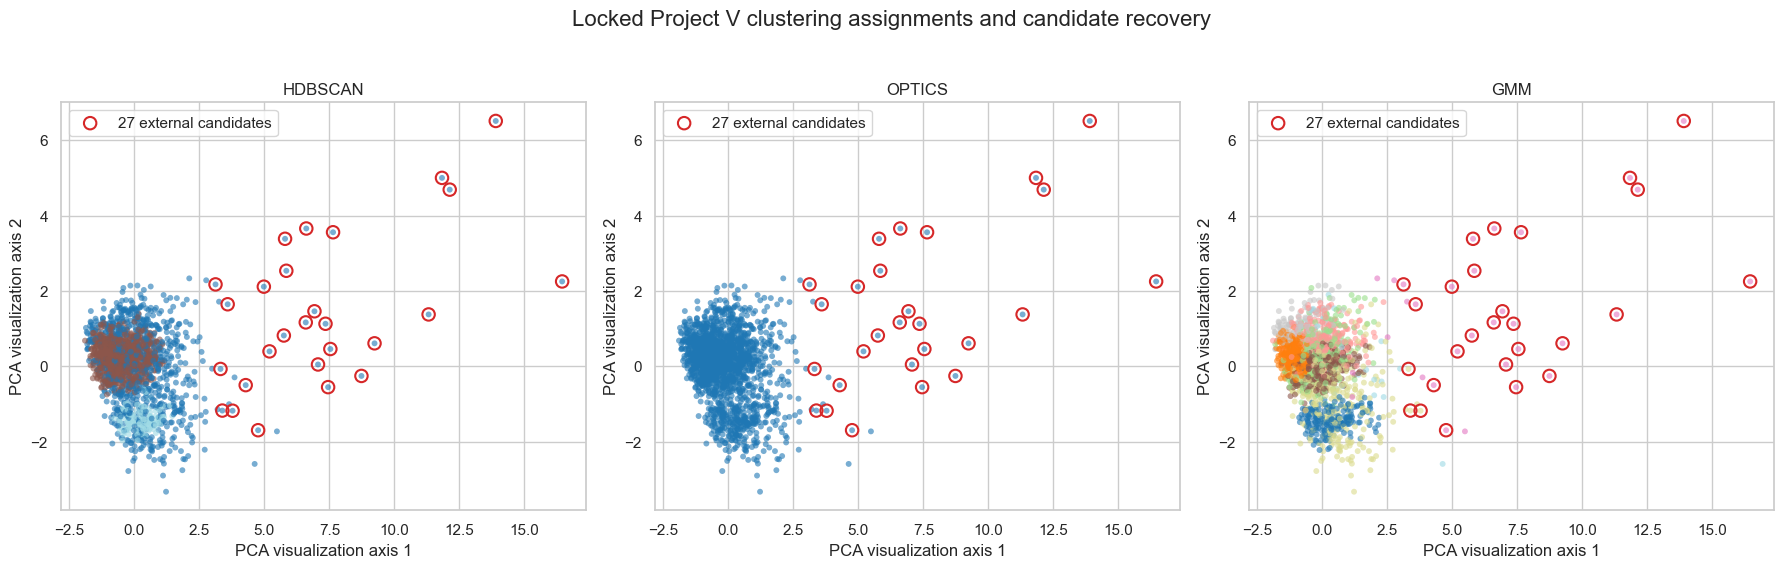

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

candidate_mask = assignments["known_candidate"].to_numpy()

fig2, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for axis, algorithm, labels in [
    (axes[0], "HDBSCAN", hdbscan_labels),
    (axes[1], "OPTICS", optics_labels),
    (axes[2], "GMM", gmm_labels),
]:
    axis.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab20",
        s=18,
        alpha=0.60,
        linewidths=0,
    )
    axis.scatter(
        X_pca[candidate_mask, 0],
        X_pca[candidate_mask, 1],
        facecolors="none",
        edgecolors="#d62728",
        s=80,
        linewidths=1.5,
        label="27 external candidates",
    )
    axis.set_title(algorithm)
    axis.set_xlabel("PCA visualization axis 1")
    axis.set_ylabel("PCA visualization axis 2")
    axis.legend(loc="best")

fig2.suptitle(
    "Locked Project V clustering assignments and candidate recovery",
    fontsize=16,
    y=1.03,
)
fig2.tight_layout()


## 11. Save Milestone 2 outputs

In [13]:
processed_dir = Path("data/processed")
figure_dir = Path("figures")

model_selection_path = (
    processed_dir / "project_v_m2_blind_model_selection.csv"
)
locked_summary_path = (
    processed_dir / "project_v_m2_locked_model_summary.csv"
)
assignments_path = (
    processed_dir / "project_v_m2_cluster_assignments.csv"
)
group_recovery_path = (
    processed_dir / "project_v_m2_candidate_recovery_by_group.csv"
)
recovery_summary_path = (
    processed_dir / "project_v_m2_candidate_recovery_summary.csv"
)
selection_figure_path = (
    figure_dir / "project_v_m2_model_selection.png"
)
recovery_figure_path = (
    figure_dir / "project_v_m2_locked_clustering_candidate_recovery.png"
)

model_selection = pd.concat(
    [hdbscan_results, optics_results, gmm_results],
    ignore_index=True,
    sort=False,
)

model_selection.to_csv(model_selection_path, index=False)
locked_summary.to_csv(locked_summary_path, index=False)
assignments.drop(columns=["source_id_key"]).to_csv(
    assignments_path,
    index=False,
)
candidate_recovery_by_group.to_csv(group_recovery_path, index=False)
candidate_recovery_summary.to_csv(recovery_summary_path, index=False)

fig.savefig(selection_figure_path, dpi=180, bbox_inches="tight")
fig2.savefig(recovery_figure_path, dpi=180, bbox_inches="tight")

for path in [
    model_selection_path,
    locked_summary_path,
    assignments_path,
    group_recovery_path,
    recovery_summary_path,
    selection_figure_path,
    recovery_figure_path,
]:
    print("Saved:", path)


Saved: data/processed/project_v_m2_blind_model_selection.csv
Saved: data/processed/project_v_m2_locked_model_summary.csv
Saved: data/processed/project_v_m2_cluster_assignments.csv
Saved: data/processed/project_v_m2_candidate_recovery_by_group.csv
Saved: data/processed/project_v_m2_candidate_recovery_summary.csv
Saved: figures/project_v_m2_model_selection.png
Saved: figures/project_v_m2_locked_clustering_candidate_recovery.png


## 12. Interpretation boundary

This milestone establishes algorithmic baseline behavior and external-candidate
recovery. A high enrichment value indicates concentration relative to the full
parent sample, but it does not by itself establish a physical stellar population.

The next milestone should test feature-space sensitivity, resampling stability,
cross-algorithm agreement, and the astrophysical properties of any repeatedly
recovered structures.
